# Poso Bacterial Profile Computations

This notebook computes descriptive results from the encoded observations in `poso_results_encoded.csv`, based on the laboratory result sheets in `RESEARCH RESULTS.pdf` and the objectives in `Copy of 3MT06_GROUP-3_RESEARCH-PAPER.pdf`.

Important limitation: these computations summarize laboratory observations. They do not perform bacterial isolation, definitive species identification, or microbial load analysis unless colony count/CFU data are added.

In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path('poso_results_encoded.csv')
df = pd.read_csv(DATA_PATH)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

df.head()

,sample_id,site,replicate,results_recorded,nutrient_growth,gram_reaction,cell_shape,arrangement,bap_growth,hemolysis,mac_growth,mac_lactose,msa_growth,mannitol,emb_growth,emb_metallic_sheen,emb_lactose,ssa_growth,ssa_lactose,h2s,tsi,sca,sim_motility,mr,vp,catalase,coagulase,oxidase,presumptive_flags,notes
0,A-1,A,1,Yes,Present,Negative,Bacilli,Diplobacilli/chain,Present,Gamma,Present,Non-lactose fermenter,Present,Negative,Present,No,Non-lactose fermenter,Present,Non-lactose fermenter,Negative,Not tested,Not tested,Positive,Negative,Negative,Negative,Not tested,Not tested,Gram-negative non-lactose fermenter; motile; H2S-negative,TSI and SCA recorded as N/A; indole not recorded.
1,A-2,A,2,Yes,Present,Negative,Bacilli,Chains,Present,Gamma,Present,Lactose fermenter,Present,Negative,Present,Yes,Strong lactose fermenter,Present,Non-lactose fermenter,Negative,A/A,Positive,Positive,Weak positive,Negative,Not recorded,Not recorded,Not recorded,Possible E. coli/coliform indicator based on EMB metallic sheen; citrate-positive; motile,Catalase/coagulase/oxidase not recorded in extracted result pages.
2,A-3,A,3,Yes,Present,Negative,Bacilli,Single/unspecified,Present,Gamma,Present,Lactose fermenter,Present,Negative,Present,Yes,Lactose fermenter,Present,Lactose fermenter,Negative,Not tested,Not tested,Positive,Positive,Negative,Negative,Not tested,Not tested,Possible E. coli/coliform indicator based on EMB metallic sheen; MR-positive; motile,TSI and SCA recorded as N/A.
3,B-1,B,1,Yes,Present,Positive,Bacilli,Unspecified,Present,Gamma,Present,Lactose fermenter,Present,Positive,Present,Yes,Lactose fermenter,Present,Non-lactose fermenter,Negative,Not tested,Not tested,Not tested,Not tested,Not tested,Positive,Positive,Positive,Possible Staphylococcus aureus indicator based on catalase/coagulase positivity; EMB suggests lactose fermenter,Some media interpretations conflict with Gram-positive stain; biochemical tests for Gram-negative panel marked N/A.
4,B-2,B,2,Yes,Present,Positive,Bacilli,Unspecified,Present,Gamma,Present,Non-lactose fermenter,Present,Positive,Present,No,Non-lactose fermenter,Present,Non-lactose fermenter,Negative,K/K,Positive,Positive,Positive,Negative,Positive,Positive,Positive,Possible Staphylococcus aureus indicator; citrate-positive; motile; non-lactose fermenter,MAC/EMB growth despite Gram-positive stain should be validated.


## Dataset Audit

In [2]:
audit = pd.DataFrame({
    'metric': [
        'Total encoded samples',
        'Samples with recorded results',
        'Samples with missing/blank results',
        'Sites represented',
        'Sites with complete recorded replicates',
    ],
    'value': [
        len(df),
        (df['results_recorded'] == 'Yes').sum(),
        (df['results_recorded'] != 'Yes').sum(),
        ', '.join(sorted(df['site'].unique())),
        ', '.join(
            site for site, g in df.groupby('site')
            if (g['results_recorded'] == 'Yes').all()
        ),
    ]
})
audit

,metric,value
0,Total encoded samples,18
1,Samples with recorded results,15
2,Samples with missing/blank results,3
3,Sites represented,"A, B, C, D, E, F"
4,Sites with complete recorded replicates,"A, B, C, D, F"


In [3]:
missing_by_site = pd.crosstab(df['site'], df['results_recorded'], margins=True)
missing_by_site

results_recorded,No,Yes,All
site,,,
A,0,3,3
B,0,3,3
C,0,3,3
D,0,3,3
E,3,0,3
F,0,3,3
All,3,15,18


## Objective Coverage

In [4]:
objective_coverage = pd.DataFrame([
    {
        'objective': '1. Isolate bacterial microorganisms from swabbed samples',
        'answerable_with_notebook': 'Partly',
        'what_notebook_can_answer': 'Summarize recorded growth/presence after lab isolation.',
        'limitation': 'Actual isolation is a wet-lab procedure and cannot be done computationally.'
    },
    {
        'objective': '2. Determine cultural and morphological characteristics',
        'answerable_with_notebook': 'Yes',
        'what_notebook_can_answer': 'Frequency and percentage summaries for Gram stain, morphology, colony/media characteristics, and hemolysis.',
        'limitation': 'Depends on accuracy/completeness of encoded lab observations.'
    },
    {
        'objective': '3. Identify biochemical characteristics',
        'answerable_with_notebook': 'Yes, descriptively',
        'what_notebook_can_answer': 'Summarize TSI, SCA, SIM, MR, VP, catalase, coagulase, and oxidase results.',
        'limitation': 'Exact species identification remains presumptive without confirmatory identification tests.'
    },
    {
        'objective': '4. Compare bacterial profiles among sampling sites',
        'answerable_with_notebook': 'Yes, with missing-data caveat',
        'what_notebook_can_answer': 'Compare profiles by site using crosstabs, percentages, binary profile matrices, and similarity scores.',
        'limitation': 'Site E is blank/missing; categorical data are not suitable for ANOVA unless numeric CFU/microbial-load data are added.'
    },
])
objective_coverage

,objective,answerable_with_notebook,what_notebook_can_answer,limitation
0,1. Isolate bacterial microorganisms from swabbed samples,Partly,Summarize recorded growth/presence after lab isolation.,Actual isolation is a wet-lab procedure and cannot be done computationally.
1,2. Determine cultural and morphological characteristics,Yes,"Frequency and percentage summaries for Gram stain, morphology, colony/media characteristics, and hemolysis.",Depends on accuracy/completeness of encoded lab observations.
2,3. Identify biochemical characteristics,"Yes, descriptively","Summarize TSI, SCA, SIM, MR, VP, catalase, coagulase, and oxidase results.",Exact species identification remains presumptive without confirmatory identification tests.
3,4. Compare bacterial profiles among sampling sites,"Yes, with missing-data caveat","Compare profiles by site using crosstabs, percentages, binary profile matrices, and similarity scores.",Site E is blank/missing; categorical data are not suitable for ANOVA unless numeric CFU/microbial-load data are added.


## Helper Functions

In [5]:
recorded = df[df['results_recorded'] == 'Yes'].copy()

def frequency_percent(data, column):
    counts = data[column].fillna('Missing').value_counts(dropna=False).rename('count')
    out = counts.to_frame()
    out['percent'] = (out['count'] / out['count'].sum() * 100).round(2)
    out.index.name = column
    return out.reset_index()

def crosstab_count_percent(data, row, column):
    counts = pd.crosstab(data[row], data[column])
    percents = pd.crosstab(data[row], data[column], normalize='index').mul(100).round(2)
    return counts, percents

def display_count_and_percent(column):
    return frequency_percent(recorded, column)

recorded[['sample_id', 'site', 'replicate', 'gram_reaction', 'cell_shape', 'hemolysis']].head()

,sample_id,site,replicate,gram_reaction,cell_shape,hemolysis
0,A-1,A,1,Negative,Bacilli,Gamma
1,A-2,A,2,Negative,Bacilli,Gamma
2,A-3,A,3,Negative,Bacilli,Gamma
3,B-1,B,1,Positive,Bacilli,Gamma
4,B-2,B,2,Positive,Bacilli,Gamma


## Objective 1: Recorded Bacterial Growth

In [6]:
growth_summary = frequency_percent(df, 'nutrient_growth')
growth_by_site_counts, growth_by_site_pct = crosstab_count_percent(df, 'site', 'nutrient_growth')

growth_summary

,nutrient_growth,count,percent
0,Present,15,83.33
1,Missing,3,16.67


In [7]:
growth_by_site_counts

nutrient_growth,Missing,Present
site,,
A,0,3
B,0,3
C,0,3
D,0,3
E,3,0
F,0,3


Interpretation support: this answers whether bacterial growth was recorded after lab isolation. It does not replace the isolation process itself.

## Objective 2: Cultural and Morphological Characteristics

In [8]:
morphology_tables = {
    'gram_reaction': display_count_and_percent('gram_reaction'),
    'cell_shape': display_count_and_percent('cell_shape'),
    'hemolysis': display_count_and_percent('hemolysis'),
    'mac_lactose': display_count_and_percent('mac_lactose'),
    'mannitol': display_count_and_percent('mannitol'),
    'emb_lactose': display_count_and_percent('emb_lactose'),
    'ssa_lactose': display_count_and_percent('ssa_lactose'),
}

morphology_tables['gram_reaction']

,gram_reaction,count,percent
0,Negative,11,73.33
1,Positive,3,20.00
2,Variable,1,6.67


In [9]:
morphology_tables['cell_shape']

,cell_shape,count,percent
0,Bacilli,12,80.00
1,Unspecified,1,6.67
2,Coccobacilli,1,6.67
3,Cocci,1,6.67


In [10]:
morphology_tables['hemolysis']

,hemolysis,count,percent
0,Gamma,15,100.0


In [11]:
media_columns = ['mac_lactose', 'mannitol', 'emb_metallic_sheen', 'emb_lactose', 'ssa_lactose']
media_summary = pd.concat(
    {col: frequency_percent(recorded, col).set_index(col) for col in media_columns},
    names=['test', 'result']
).reset_index()
media_summary

,test,result,count,percent
0,mac_lactose,Non-lactose fermenter,8,53.33
1,mac_lactose,Lactose fermenter,5,33.33
2,mac_lactose,Mixed,2,13.33
3,mannitol,Negative,10,66.67
4,mannitol,Positive,2,13.33
5,mannitol,Not applicable,2,13.33
6,mannitol,Indeterminate,1,6.67
7,emb_metallic_sheen,No,10,66.67
8,emb_metallic_sheen,Yes,5,33.33
9,emb_lactose,Non-lactose fermenter,9,60.00


## Objective 3: Biochemical Characteristics

In [12]:
biochemical_columns = ['tsi', 'sca', 'sim_motility', 'mr', 'vp', 'catalase', 'coagulase', 'oxidase', 'h2s']
biochemical_summary = pd.concat(
    {col: frequency_percent(recorded, col).set_index(col) for col in biochemical_columns},
    names=['test', 'result']
).reset_index()
biochemical_summary

,test,result,count,percent
0,tsi,Not recorded,5,33.33
1,tsi,Not tested,4,26.67
2,tsi,K/K,4,26.67
3,tsi,A/A,2,13.33
4,sca,Not tested,4,26.67
5,sca,Positive,4,26.67
6,sca,Negative,4,26.67
7,sca,Not recorded,3,20.00
8,sim_motility,Positive,13,86.67
9,sim_motility,Not tested,1,6.67


In [13]:
biochemical_by_site = {}
for col in biochemical_columns:
    biochemical_by_site[col] = pd.crosstab(recorded['site'], recorded[col])

biochemical_by_site['oxidase']

oxidase,Negative,Not recorded,Not tested,Positive
site,,,,
A,0,1,2,0
B,1,0,0,2
C,0,0,0,3
D,3,0,0,0
F,0,0,0,3


## Objective 4: Site Profile Comparison

In [14]:
comparison_columns = [
    'gram_reaction', 'cell_shape', 'hemolysis', 'mac_lactose', 'mannitol',
    'emb_metallic_sheen', 'emb_lactose', 'ssa_lactose', 'h2s', 'tsi', 'sca',
    'sim_motility', 'mr', 'vp', 'catalase', 'coagulase', 'oxidase'
]

site_profile_mode = recorded.groupby('site')[comparison_columns].agg(lambda s: s.mode().iat[0] if not s.mode().empty else 'Missing')
site_profile_mode

,gram_reaction,cell_shape,hemolysis,mac_lactose,mannitol,emb_metallic_sheen,emb_lactose,ssa_lactose,h2s,tsi,sca,sim_motility,mr,vp,catalase,coagulase,oxidase
site,,,,,,,,,,,,,,,,,
A,Negative,Bacilli,Gamma,Lactose fermenter,Negative,Yes,Lactose fermenter,Non-lactose fermenter,Negative,Not tested,Not tested,Positive,Negative,Negative,Negative,Not tested,Not tested
B,Positive,Bacilli,Gamma,Non-lactose fermenter,Positive,No,Non-lactose fermenter,Non-lactose fermenter,Negative,K/K,Not recorded,Positive,Negative,Negative,Positive,Positive,Positive
C,Negative,Bacilli,Gamma,Mixed,Not applicable,No,Non-lactose fermenter,Non-lactose fermenter,Negative,Not recorded,Not recorded,Positive,Positive,Negative,Negative,Negative,Positive
D,Negative,Bacilli,Gamma,Non-lactose fermenter,Negative,No,Non-lactose fermenter,Mixed,Negative,Not recorded,Negative,Positive,Negative,Negative,Positive,Positive,Negative
F,Negative,Bacilli,Gamma,Non-lactose fermenter,Negative,No,Indeterminate,Non-lactose fermenter,Negative,K/K,Negative,Positive,Negative,Negative,Positive,Negative,Positive


In [15]:
gram_by_site_counts, gram_by_site_pct = crosstab_count_percent(recorded, 'site', 'gram_reaction')
gram_by_site_counts

gram_reaction,Negative,Positive,Variable
site,,,
A,3,0,0
B,1,2,0
C,3,0,0
D,2,1,0
F,2,0,1


In [16]:
mac_by_site_counts, mac_by_site_pct = crosstab_count_percent(recorded, 'site', 'mac_lactose')
mac_by_site_counts

mac_lactose,Lactose fermenter,Mixed,Non-lactose fermenter
site,,,
A,2,0,1
B,1,0,2
C,1,2,0
D,0,0,3
F,1,0,2


In [17]:
indicator_flags = recorded[['sample_id', 'site', 'presumptive_flags', 'notes']].copy()
indicator_flags

,sample_id,site,presumptive_flags,notes
0,A-1,A,Gram-negative non-lactose fermenter; motile; H2S-negative,TSI and SCA recorded as N/A; indole not recorded.
1,A-2,A,Possible E. coli/coliform indicator based on EMB metallic sheen; citrate-positive; motile,Catalase/coagulase/oxidase not recorded in extracted result pages.
2,A-3,A,Possible E. coli/coliform indicator based on EMB metallic sheen; MR-positive; motile,TSI and SCA recorded as N/A.
3,B-1,B,Possible Staphylococcus aureus indicator based on catalase/coagulase positivity; EMB suggests lactose fermenter,Some media interpretations conflict with Gram-positive stain; biochemical tests for Gram-negative panel marked N/A.
4,B-2,B,Possible Staphylococcus aureus indicator; citrate-positive; motile; non-lactose fermenter,MAC/EMB growth despite Gram-positive stain should be validated.
5,B-3,B,Gram-negative non-lactose fermenter; catalase-positive; oxidase-negative,TSI and SCA not recorded.
6,C-1,C,Mixed MAC growth; possible non-lactose fermenter; oxidase-positive; possible Shigella noted in source,MSA yellow colonies but no medium change; species call should be treated as presumptive.
7,C-2,C,Possible E. coli indicator based on EMB metallic sheen; mixed MAC growth; oxidase-positive,TSI and SCA not recorded.
8,C-3,C,Lactose fermenter on MAC/SSA; citrate-positive; oxidase-positive; MR-positive,"EMB did not show metallic sheen, so E. coli was marked negative in source."
9,D-1,D,Non-lactose fermenter; catalase/coagulase-positive; oxidase-negative,BAP interpretation mentions Gram-positive despite Gram stain reporting Gram-negative coccobacilli.


In [18]:
binary_features = pd.DataFrame({
    'sample_id': recorded['sample_id'],
    'site': recorded['site'],
    'gram_negative': recorded['gram_reaction'].eq('Negative').astype(int),
    'gram_positive': recorded['gram_reaction'].eq('Positive').astype(int),
    'mac_lactose_fermenter': recorded['mac_lactose'].eq('Lactose fermenter').astype(int),
    'mac_non_lactose_fermenter': recorded['mac_lactose'].eq('Non-lactose fermenter').astype(int),
    'emb_metallic_sheen': recorded['emb_metallic_sheen'].eq('Yes').astype(int),
    'h2s_positive': recorded['h2s'].eq('Positive').astype(int),
    'motile': recorded['sim_motility'].eq('Positive').astype(int),
    'mr_positive': recorded['mr'].isin(['Positive', 'Weak positive']).astype(int),
    'vp_positive': recorded['vp'].eq('Positive').astype(int),
    'catalase_positive': recorded['catalase'].eq('Positive').astype(int),
    'coagulase_positive': recorded['coagulase'].eq('Positive').astype(int),
    'oxidase_positive': recorded['oxidase'].eq('Positive').astype(int),
})

site_binary_profile = binary_features.drop(columns=['sample_id']).groupby('site').mean().round(2)
site_binary_profile

,gram_negative,gram_positive,mac_lactose_fermenter,mac_non_lactose_fermenter,emb_metallic_sheen,h2s_positive,motile,mr_positive,vp_positive,catalase_positive,coagulase_positive,oxidase_positive
site,,,,,,,,,,,,
A,1.00,0.00,0.67,0.33,0.67,0.0,1.00,0.67,0.0,0.0,0.00,0.00
B,0.33,0.67,0.33,0.67,0.33,0.0,0.67,0.33,0.0,1.0,0.67,0.67
C,1.00,0.00,0.33,0.00,0.33,0.0,1.00,1.00,0.0,0.0,0.00,1.00
D,0.67,0.33,0.00,1.00,0.00,0.0,0.67,0.00,0.0,1.0,0.67,0.00
F,0.67,0.00,0.33,0.67,0.33,0.0,1.00,0.33,0.0,1.0,0.00,1.00


In [19]:
# Jaccard similarity by site using binary profile features.
feature_cols = site_binary_profile.columns
site_binary_presence = (site_binary_profile > 0).astype(int)

similarity = pd.DataFrame(index=site_binary_presence.index, columns=site_binary_presence.index, dtype=float)
for site_a in site_binary_presence.index:
    for site_b in site_binary_presence.index:
        a = site_binary_presence.loc[site_a, feature_cols].astype(bool)
        b = site_binary_presence.loc[site_b, feature_cols].astype(bool)
        union = (a | b).sum()
        similarity.loc[site_a, site_b] = ((a & b).sum() / union) if union else 0

similarity.round(2)

site,A,B,C,D,F
site,,,,,
A,1.00,0.6,0.71,0.33,0.75
B,0.60,1.0,0.60,0.60,0.80
C,0.71,0.6,1.00,0.20,0.75
D,0.33,0.6,0.20,1.00,0.40
F,0.75,0.8,0.75,0.40,1.00


## ANOVA Suitability Check

In [20]:
anova_check = pd.DataFrame([
    {
        'planned_analysis': 'ANOVA for microbial load comparison',
        'suitable_with_current_data': 'No',
        'reason': 'The encoded results are categorical observations, not numeric CFU or microbial-load measurements.',
        'needed_to_make_it_suitable': 'Add numeric colony counts, dilution factors, swabbed surface area, and computed CFU/cm^2 or comparable microbial-load values.'
    },
    {
        'planned_analysis': 'Frequency counts and percentages',
        'suitable_with_current_data': 'Yes',
        'reason': 'The results are mostly present/absent, positive/negative, and categorical media observations.',
        'needed_to_make_it_suitable': 'No additional numeric data required, but missing entries should be completed where possible.'
    },
    {
        'planned_analysis': 'Chi-square or Fisher exact tests',
        'suitable_with_current_data': 'Limited',
        'reason': 'The sample size is small and Site E is missing; many expected counts may be too low.',
        'needed_to_make_it_suitable': 'More complete samples per site or a narrower categorical comparison.'
    },
])
anova_check

,planned_analysis,suitable_with_current_data,reason,needed_to_make_it_suitable
0,ANOVA for microbial load comparison,No,"The encoded results are categorical observations, not numeric CFU or microbial-load measurements.","Add numeric colony counts, dilution factors, swabbed surface area, and computed CFU/cm^2 or comparable microbial-loa..."
1,Frequency counts and percentages,Yes,"The results are mostly present/absent, positive/negative, and categorical media observations.","No additional numeric data required, but missing entries should be completed where possible."
2,Chi-square or Fisher exact tests,Limited,The sample size is small and Site E is missing; many expected counts may be too low.,More complete samples per site or a narrower categorical comparison.


## Optional Charts

These cells run only if plotting libraries are installed in your Jupyter environment.

In [21]:
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception:
    HAS_MATPLOTLIB = False

HAS_MATPLOTLIB

True

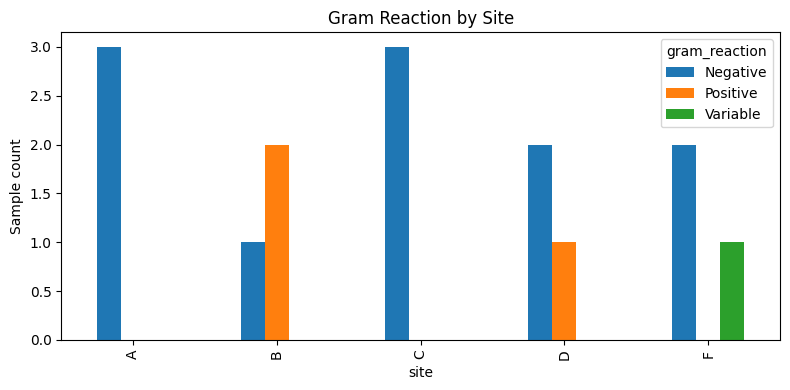

In [22]:
if HAS_MATPLOTLIB:
    gram_by_site_counts.plot(kind='bar', figsize=(8, 4), title='Gram Reaction by Site')
    plt.ylabel('Sample count')
    plt.tight_layout()
    plt.show()
else:
    print('Install matplotlib to render this chart.')

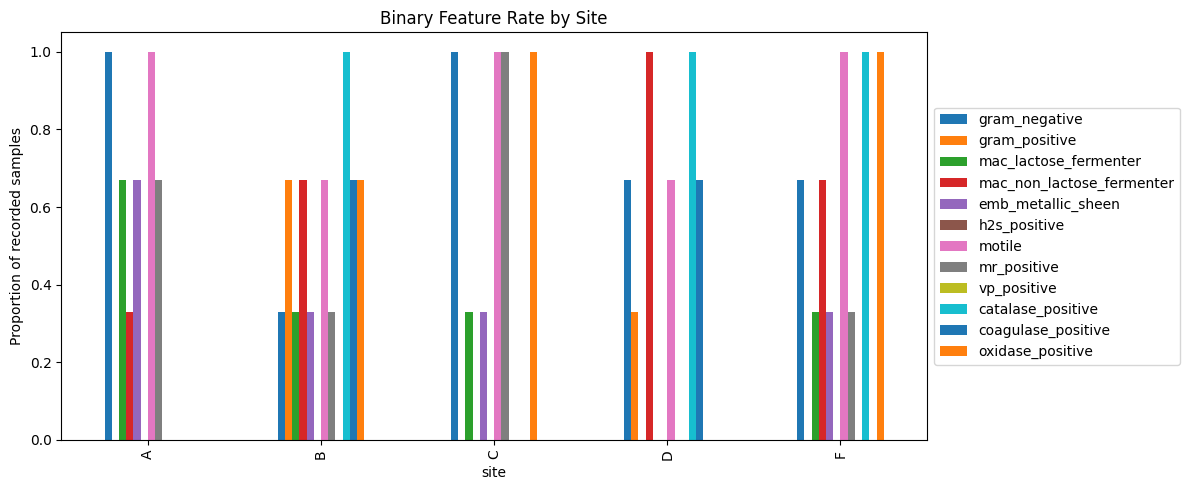

In [23]:
if HAS_MATPLOTLIB:
    site_binary_profile.plot(kind='bar', figsize=(12, 5), title='Binary Feature Rate by Site')
    plt.ylabel('Proportion of recorded samples')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()
else:
    print('Install matplotlib to render this chart.')

## Export Computed Tables

In [24]:
OUTPUT_DIR = Path('computed_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

tables = {
    'audit.csv': audit,
    'objective_coverage.csv': objective_coverage,
    'missing_by_site.csv': missing_by_site.reset_index(),
    'growth_summary.csv': growth_summary,
    'growth_by_site_counts.csv': growth_by_site_counts.reset_index(),
    'media_summary.csv': media_summary,
    'biochemical_summary.csv': biochemical_summary,
    'site_profile_mode.csv': site_profile_mode.reset_index(),
    'gram_by_site_counts.csv': gram_by_site_counts.reset_index(),
    'mac_by_site_counts.csv': mac_by_site_counts.reset_index(),
    'indicator_flags.csv': indicator_flags,
    'site_binary_profile.csv': site_binary_profile.reset_index(),
    'site_similarity_jaccard.csv': similarity.round(2).reset_index(),
    'anova_suitability_check.csv': anova_check,
}

for filename, table in tables.items():
    table.to_csv(OUTPUT_DIR / filename, index=False)

excel_path = OUTPUT_DIR / 'poso_computed_tables.xlsx'
try:
    with pd.ExcelWriter(excel_path) as writer:
        for filename, table in tables.items():
            sheet_name = filename.replace('.csv', '')[:31]
            table.to_excel(writer, sheet_name=sheet_name, index=False)
    export_status = f'CSV files and Excel workbook exported to {OUTPUT_DIR}'
except Exception as exc:
    export_status = f'CSV files exported. Excel export skipped: {exc}'

export_status, sorted(p.name for p in OUTPUT_DIR.glob('*'))

('CSV files and Excel workbook exported to computed_outputs',
 ['anova_suitability_check.csv',
  'audit.csv',
  'biochemical_summary.csv',
  'gram_by_site_counts.csv',
  'growth_by_site_counts.csv',
  'growth_summary.csv',
  'indicator_flags.csv',
  'mac_by_site_counts.csv',
  'media_summary.csv',
  'missing_by_site.csv',
  'objective_coverage.csv',
  'poso_computed_tables.xlsx',
  'site_binary_profile.csv',
  'site_profile_mode.csv',
  'site_similarity_jaccard.csv',
  '~$poso_computed_tables.xlsx'])